In [1]:
import pandas as pd
import numpy as np
import os
import typing
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

2025-08-02 19:42:18.397117: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-02 19:42:18.398483: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-02 19:42:18.405033: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-02 19:42:18.423313: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754163738.455411  498247 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754163738.46

In [2]:
# Define file paths
population_file = '../Data/population_with_latlong.csv'
dengue_file = '../Data/reshaped_dengue_data.csv'

# Load the datasets into pandas DataFrames
population_df = pd.read_csv(population_file)
dengue_df = pd.read_csv(dengue_file)

dengue_array = dengue_df.drop("date", axis=1).values.astype("float32")
print(f"(timesteps, localities): {dengue_array.shape}")

# Define the split point
train_val_size = 200

# Create the training/validation set and the final hold-out test set
train_val_array = dengue_array[:train_val_size]
test_array = dengue_array[train_val_size:]

print(f"\nTraining/Validation set shape: {train_val_array.shape}")
print(f"Hold-Out Test set shape: {test_array.shape}")

(timesteps, localities): (228, 558)

Training/Validation set shape: (200, 558)
Hold-Out Test set shape: (28, 558)


Preprocess

In [3]:
# def preprocess(data_array: np.ndarray):
#     """
#     Splits data into train/val sets based on fractions and normalizes the data.
#     """
#     num_time_steps = data_array.shape[0]
#     num_train = 160
#     num_val = 34

#     # Split the data
#     train_array = data_array[:num_train]
#     val_array = data_array[num_train : num_train + num_val]
#     # The rest of the data can be used as a test set if needed
#     # test_array = data_array[num_train + num_val:]

#     # Normalize based on the training data ONLY to prevent data leakage
#     mean = train_array.mean(axis=0)
#     std = train_array.std(axis=0)

#     # Handle cases where standard deviation is zero to avoid division by zero
#     std[std == 0] = 1.0

#     train_array_normalized = (train_array - mean) / std
#     val_array_normalized = (val_array - mean) / std
    
#     # We return the mean and std to de-normalize predictions later
#     return train_array_normalized, val_array_normalized, mean, std

# #Apply the preprocessing function to the data
# train_array, val_array, mean_vals, std_vals = preprocess(dengue_array)

# print(f"Train array shape: {train_array.shape}")
# print(f"Validation array shape: {val_array.shape}\n")

Creating tf dataset

In [4]:
# Define hyperparameters for creating the time-series sequences
input_sequence_length = 12
forecast_horizon = 3
batch_size = 32


# Define the function to create TensorFlow datasets
def create_tf_dataset(
    data_array: np.ndarray,
    input_sequence_length: int,
    forecast_horizon: int,
    batch_size: int = 32,
    shuffle=True,
    multi_horizon=True,
):
    """Creates a TensorFlow dataset from a NumPy array."""
    
    # Create inputs using sliding windows on the data array
    inputs = tf.keras.preprocessing.timeseries_dataset_from_array(
        np.expand_dims(data_array[:-forecast_horizon], axis=-1),
        None,
        sequence_length=input_sequence_length,
        shuffle=False,
        batch_size=batch_size,
    )

    # Determine the starting point for the target sequences
    target_offset = (
        input_sequence_length if multi_horizon else input_sequence_length + forecast_horizon - 1
    )
    target_seq_length = forecast_horizon if multi_horizon else 1
    
    # Create targets using sliding windows
    targets = tf.keras.preprocessing.timeseries_dataset_from_array(
        data_array[target_offset:],
        None,
        sequence_length=target_seq_length,
        shuffle=False,
        batch_size=batch_size,
    )

    # Zip inputs and targets together into a single dataset
    dataset = tf.data.Dataset.zip((inputs, targets))
    if shuffle:
        dataset = dataset.shuffle(100)

    # Prefetch and cache for performance
    return dataset.prefetch(16).cache()


# # Create the final training and validation datasets
# train_dataset = create_tf_dataset(
#     train_array, input_sequence_length, forecast_horizon, batch_size, multi_horizon=False
# )
# val_dataset = create_tf_dataset(
#     val_array, input_sequence_length, forecast_horizon, batch_size, shuffle=False, multi_horizon=False
# )

# print("TensorFlow datasets created successfully.")

Gravity Model

In [5]:
def create_gravity_adjacency_matrix(
    df: pd.DataFrame, 
    population_col='population', 
    lat_col='latitude', 
    lon_col='longitude',
    p_cutoff=90 # Keep the top 5% of all weighted edges (100 - 95)
):
    """
    Creates a sparse, row-normalized, weighted adjacency matrix based on a gravity model,
    keeping only the edges with weights above a certain percentile cutoff.
    """
    num_nodes = len(df)
    populations = df[population_col].values
    coords = np.radians(df[[lat_col, lon_col]].values)

    # 1. Calculate the pairwise Haversine distance matrix
    lat = coords[:, 0]
    lon = coords[:, 1]
    dlat = lat[:, np.newaxis] - lat
    dlon = lon[:, np.newaxis] - lon
    a = np.sin(dlat / 2.0)**2 + np.cos(lat[:, np.newaxis]) * np.cos(lat) * np.sin(dlon / 2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    distance_matrix = 6371 * c

    # 2. Calculate the population interaction term
    pop_matrix = np.outer(populations, populations)

    # 3. Calculate the gravity model scores
    with np.errstate(divide='ignore', invalid='ignore'):
        gravity_matrix = pop_matrix / (distance_matrix**2)
    np.fill_diagonal(gravity_matrix, 0)
    gravity_matrix[~np.isfinite(gravity_matrix)] = 0
    
    # --- NEW: Sparsify the Graph ---
    # 4. Keep only the most significant edges
    # Find the cutoff value at the specified percentile of non-zero edges
    all_edges = gravity_matrix[gravity_matrix > 0]
    cutoff_value = np.percentile(all_edges, p_cutoff)
    
    # Create a new sparse matrix by setting all values below the cutoff to 0
    sparse_gravity_matrix = gravity_matrix.copy()
    sparse_gravity_matrix[sparse_gravity_matrix < cutoff_value] = 0

    # 5. Re-normalize the sparse matrix by row
    row_sums = sparse_gravity_matrix.sum(axis=1)
    row_sums[row_sums == 0] = 1.0 # Avoid division by zero
    
    normalized_adj_matrix = sparse_gravity_matrix / row_sums[:, np.newaxis]
    
    return normalized_adj_matrix

# --- Graph Initialization with Weights ---

# 1. Create the weighted adjacency matrix
weighted_adjacency_matrix = create_gravity_adjacency_matrix(population_df)

# 2. Update GraphInfo to store edge weights
class GraphInfo:
    def __init__(self, edges: typing.Tuple[list, list], edge_weights: list, num_nodes: int):
        self.edges = edges
        self.edge_weights = edge_weights
        self.num_nodes = num_nodes

# 3. Find the indices (edges) and their corresponding weights from the matrix
# We find all connections where the gravity score is greater than zero
node_indices, neighbor_indices = np.where(weighted_adjacency_matrix > 0)
edge_weights = weighted_adjacency_matrix[node_indices, neighbor_indices]

# 4. Create the graph object with the edge weights
graph = GraphInfo(
    edges=(node_indices.tolist(), neighbor_indices.tolist()),
    edge_weights=edge_weights.tolist(),
    num_nodes=weighted_adjacency_matrix.shape[0],
)

print(f"Weighted adjacency matrix created with shape: {weighted_adjacency_matrix.shape}")
print(f"Graph initialized with {graph.num_nodes} nodes and {len(graph.edges[0])} weighted edges.")

Weighted adjacency matrix created with shape: (558, 558)
Graph initialized with 558 nodes and 31082 weighted edges.


GraphConv

In [6]:
class GraphConv(layers.Layer):
    def __init__(
        self,
        in_feat,
        out_feat,
        graph_info: GraphInfo,
        combination_type="concat",
        activation: typing.Optional[str] = None,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.in_feat = in_feat
        self.out_feat = out_feat
        self.graph_info = graph_info
        self.combination_type = combination_type
        
        self.edge_weights = tf.constant(graph_info.edge_weights, dtype="float32")

        self.weight = tf.Variable(
            initial_value=keras.initializers.glorot_uniform()(
                shape=(in_feat, out_feat), dtype="float32"
            ),
            trainable=True,
        )
        self.activation = layers.Activation(activation)

    def aggregate(self, neighbour_representations: tf.Tensor):
        """
        Performs a weighted aggregation of neighbor features.
        The formula is: sum(features * weights) / sum(weights)
        """
        # Reshape edge weights to multiply with neighbor features
        weights_reshaped = tf.reshape(self.edge_weights, (-1, 1, 1, 1))
        weighted_neighbors = neighbour_representations * weights_reshaped
        
        # Calculate the numerator of the weighted mean
        numerator = tf.math.unsorted_segment_sum(
            data=weighted_neighbors,
            segment_ids=self.graph_info.edges[0],
            num_segments=self.graph_info.num_nodes
        )
        
        # --- CORRECTED PART ---
        # Calculate the denominator (sum of weights for each node)
        denominator = tf.math.unsorted_segment_sum(
            data=self.edge_weights,
            segment_ids=self.graph_info.edges[0],
            num_segments=self.graph_info.num_nodes
        )
        
        # Reshape denominator for broadcasting across all dimensions
        # Shape changes from (num_nodes,) to (num_nodes, 1, 1, 1)
        denominator_reshaped = tf.reshape(denominator, (-1, 1, 1, 1))
        
        # Avoid division by zero
        denominator_reshaped = tf.where(denominator_reshaped == 0, 1.0, denominator_reshaped)
        
        return numerator / denominator_reshaped

    def compute_nodes_representation(self, features: tf.Tensor):
        return tf.matmul(features, self.weight)

    def compute_aggregated_messages(self, features: tf.Tensor):
        neighbour_representations = tf.gather(features, self.graph_info.edges[1])
        aggregated_messages = self.aggregate(neighbour_representations)
        return tf.matmul(aggregated_messages, self.weight)

    def update(self, nodes_representation: tf.Tensor, aggregated_messages: tf.Tensor):
        if self.combination_type == "concat":
            h = tf.concat([nodes_representation, aggregated_messages], axis=-1)
        elif self.combination_type == "add":
            h = nodes_representation + aggregated_messages
        else:
            raise ValueError(f"Invalid combination type: {self.combination_type}.")
        return self.activation(h)

    def call(self, features: tf.Tensor):
        nodes_representation = self.compute_nodes_representation(features)
        aggregated_messages = self.compute_aggregated_messages(features)
        return self.update(nodes_representation, aggregated_messages)

In [7]:
class LSTMGC(layers.Layer):
    """Layer comprising a graph convolution layer followed by an LSTM and dense layer."""

    def __init__(
        self,
        in_feat,
        out_feat,
        lstm_units: int,
        input_seq_len: int,
        output_seq_len: int,
        graph_info: GraphInfo,
        **kwargs,
    ):
        super().__init__(**kwargs)

        self.graph_conv = GraphConv(in_feat, out_feat, graph_info)
        self.lstm = layers.LSTM(lstm_units, activation="relu")
        self.dense = layers.Dense(output_seq_len)
        self.input_seq_len = input_seq_len
        self.output_seq_len = output_seq_len

    def call(self, inputs):
        """Forward pass."""
        # Reshape for GraphConv
        inputs = tf.transpose(inputs, [2, 0, 1, 3])

        gcn_out = self.graph_conv(inputs)
        
        shape = tf.shape(gcn_out)
        num_nodes, batch_size, input_seq_len, out_feat = (
            shape[0], shape[1], shape[2], shape[3]
        )

        # Reshape for LSTM
        gcn_out = tf.reshape(gcn_out, (batch_size * num_nodes, input_seq_len, out_feat))
        lstm_out = self.lstm(gcn_out)

        # Final prediction
        dense_output = self.dense(lstm_out)
        output = tf.reshape(dense_output, (num_nodes, batch_size, self.output_seq_len))
        
        # Reshape back to a user-friendly format
        return tf.transpose(output, [1, 2, 0])

print("LSTMGC layer defined successfully.")

LSTMGC layer defined successfully.


In [8]:
# --- New Cell for Cross-Validation ---
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler
import time

# --- 1. Define Model Hyperparameters ---
in_feat = 1
out_feat = 4
lstm_units = 32
epochs = 20
output_sequence_length = 1
input_sequence_length = 12
forecast_horizon = 3
batch_size = 32

# --- 2. Set up Time Series Cross-Validation ---
n_splits = 3
tscv = TimeSeriesSplit(n_splits=n_splits)

validation_scores = []
print(f"Starting Time Series Cross-Validation with {n_splits} splits...")
print("This will take a few moments as the model is trained multiple times.")

for fold, (train_indices, val_indices) in enumerate(tscv.split(train_val_array)):
    print(f"\n--- FOLD {fold + 1}/{n_splits} ---")
    
    # Create and preprocess data for the current fold
    train_fold, val_fold = train_val_array[train_indices], train_val_array[val_indices]
    scaler = MinMaxScaler()
    train_fold_norm = scaler.fit_transform(train_fold)
    val_fold_norm = scaler.transform(val_fold)
    
    # Create TensorFlow datasets for the current fold
    train_dataset = create_tf_dataset(train_fold_norm, input_sequence_length, forecast_horizon, batch_size, multi_horizon=False)
    val_dataset = create_tf_dataset(val_fold_norm, input_sequence_length, forecast_horizon, batch_size, shuffle=False, multi_horizon=False)
    
    # Re-initialize and train the model for this fold
    input_layer = layers.Input(shape=(input_sequence_length, graph.num_nodes, in_feat))
    st_gcn_layer = LSTMGC(in_feat, out_feat, lstm_units, input_sequence_length, output_sequence_length, graph)
    outputs = st_gcn_layer(input_layer)
    model = keras.models.Model(inputs=input_layer, outputs=outputs)
    
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss=keras.losses.MeanSquaredError())
    
    model.fit(train_dataset, epochs=epochs, validation_data=val_dataset,
              callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)])
    
    # Evaluate and store the score for this fold
    x_val, y_val_true_norm = next(iter(val_dataset))
    y_val_pred_norm = model.predict(x_val)

    pred_denorm = scaler.inverse_transform(y_val_pred_norm.reshape(-1, graph.num_nodes)).reshape(y_val_pred_norm.shape)
    true_denorm = scaler.inverse_transform(y_val_true_norm.numpy().reshape(-1, graph.num_nodes)).reshape(y_val_true_norm.shape)
    
    fold_mae = np.mean(np.abs(pred_denorm - true_denorm))
    validation_scores.append(fold_mae)
    print(f"MAE for Fold {fold + 1}: {fold_mae:.2f} cases")

# --- Final Cross-Validation Performance ---
print("\n--- Cross-Validation Summary ---")
print(f"Validation MAE scores for each fold: {[f'{s:.2f}' for s in validation_scores]}")
print(f"Average Validation MAE: {np.mean(validation_scores):.2f} cases")

Starting Time Series Cross-Validation with 3 splits...
This will take a few moments as the model is trained multiple times.

--- FOLD 1/3 ---


2025-08-02 19:42:20.962194: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 532ms/step - loss: 0.0437 - val_loss: 27.8470
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - loss: 0.0416 - val_loss: 28.2198
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - loss: 0.0401 - val_loss: 28.6791
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - loss: 0.0390 - val_loss: 29.2818
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - loss: 0.0386 - val_loss: 29.8277
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - loss: 0.0386 - val_loss: 30.1266
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - loss: 0.0389 - val_loss: 30.0463
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - loss: 0.0390 - val_loss: 29.6790
Epoch 9/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - loss: 0.0389 - val_loss: 29.2845
Epoch 10/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - loss: 0.0386 - val_loss: 28.9250
Epoch 11/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - loss: 0.0383 - val_loss: 28.5847
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step
MAE for Fold 1: 79.78 ca

In [9]:
# --- 1. Define Model Hyperparameters ---
in_feat = 1
out_feat = 4
lstm_units = 32
epochs = 20
output_sequence_length = 1
input_sequence_length = 12
forecast_horizon = 3
batch_size = 32

# --- New Cell for Final Model Training and Testing ---
print("\n--- Final Model Training ---")

# 1. Prepare the full training/validation dataset
full_train_val_scaler = MinMaxScaler()
full_train_val_norm = full_train_val_scaler.fit_transform(train_val_array)
full_train_dataset = create_tf_dataset(full_train_val_norm, input_sequence_length, forecast_horizon, batch_size, multi_horizon=False)

# 2. Re-initialize and train the final model on ALL training/validation data
final_input_layer = layers.Input(shape=(input_sequence_length, graph.num_nodes, in_feat))
final_st_gcn_layer = LSTMGC(in_feat, out_feat, lstm_units, input_sequence_length, output_sequence_length, graph)
final_outputs = final_st_gcn_layer(final_input_layer)
final_model = keras.models.Model(inputs=final_input_layer, outputs=final_outputs)
final_model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss=keras.losses.MeanAbsoluteError())

print("Training final model on all 200 time steps...")
final_model.fit(full_train_dataset, epochs=epochs, 
                callbacks=[keras.callbacks.EarlyStopping(monitor="loss", patience=5)], # Monitor training loss
                verbose=0)



--- Final Model Training ---
Training final model on all 200 time steps...



--- Final Evaluation on Hold-Out Test Set ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Final Hold-Out Test MAE: 189.79 cases
Final Hold-Out Test sMAPE: 128.53%
Final Hold-Out Test MASE: 2.96 (Value < 1 is better than a naive forecast)


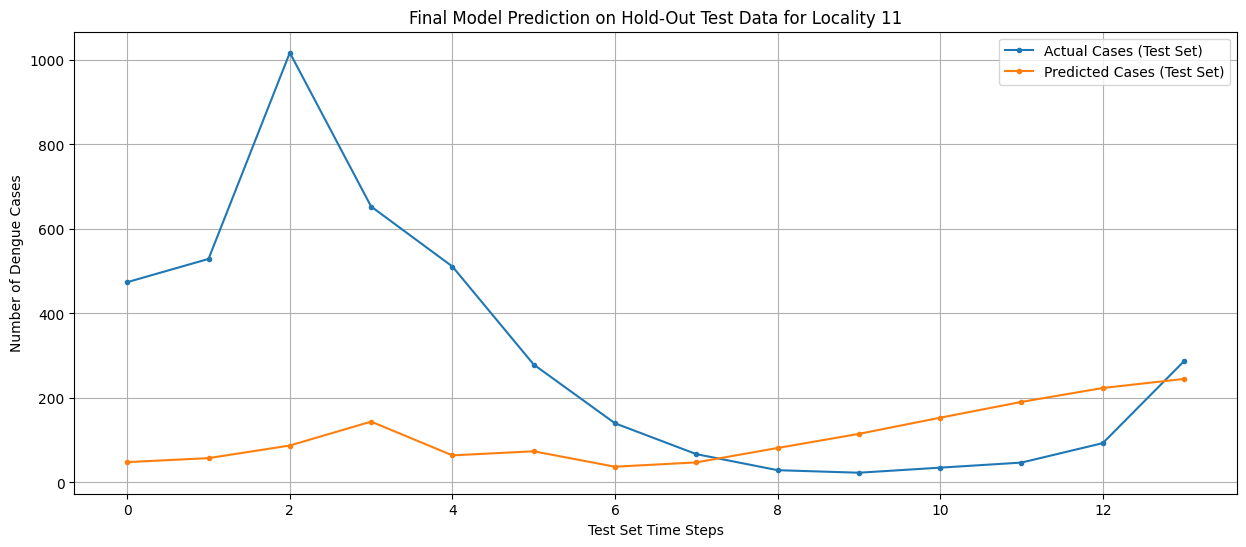

In [15]:
# --- Final Evaluation on the Hold-Out Test Set ---
print("\n--- Final Evaluation on Hold-Out Test Set ---")

# 3. Prepare the test dataset
test_norm = full_train_val_scaler.transform(test_array) # Use the SAME scaler
test_dataset = create_tf_dataset(test_norm, input_sequence_length, forecast_horizon, batch_size, shuffle=False, multi_horizon=False)

# 4. Evaluate the model
x_test, y_test_true_norm = next(iter(test_dataset))
y_test_pred_norm = final_model.predict(x_test)

# De-normalize using the scaler fit on the training/validation data
pred_denorm_test = full_train_val_scaler.inverse_transform(y_test_pred_norm.reshape(-1, graph.num_nodes)).reshape(y_test_pred_norm.shape)
true_denorm_test = full_train_val_scaler.inverse_transform(y_test_true_norm.numpy().reshape(-1, graph.num_nodes)).reshape(y_test_true_norm.shape)
pred_denorm_test = np.maximum(0, pred_denorm_test) # Clip negatives

# 5. Report final metrics
# Mean Absolute Error (MAE)
final_mae = np.mean(np.abs(pred_denorm_test - true_denorm_test))

# Symmetric Mean Absolute Percentage Error (sMAPE)
epsilon = 1e-8 # Small value to avoid division by zero
final_smape = np.mean(2 * np.abs(pred_denorm_test - true_denorm_test) / (np.abs(true_denorm_test) + np.abs(pred_denorm_test) + epsilon)) * 100

# Mean Absolute Scaled Error (MASE)
# The scaling factor is the MAE of a naive forecast on the *training* data
naive_error = np.mean(np.abs(train_val_array[1:] - train_val_array[:-1]))
final_mase = final_mae / naive_error

print(f"Final Hold-Out Test MAE: {final_mae:.2f} cases")
print(f"Final Hold-Out Test sMAPE: {final_smape:.2f}%")
print(f"Final Hold-Out Test MASE: {final_mase:.2f} (Value < 1 is better than a naive forecast)")


# 6. Visualize final results
locality_index = 11
plt.figure(figsize=(15, 6))
plt.plot(true_denorm_test[:, :, locality_index].flatten(), label="Actual Cases (Test Set)", marker='.')
plt.plot(pred_denorm_test[:, :, locality_index].flatten(), label="Predicted Cases (Test Set)", marker='.')
plt.title(f'Final Model Prediction on Hold-Out Test Data for Locality {locality_index}')
plt.xlabel("Test Set Time Steps")
plt.ylabel("Number of Dengue Cases")
plt.legend()
plt.grid(True)
plt.show()